In [ ]:
import numpy as np
from scipy.special import hyp2f1
import dadi.Polyploidy
import dadi
import matplotlib.pyplot as plt

In [ ]:
# Set of functions for testing the accuracy of the dadi results
# benchmarked against Kimura's 1964 eigenfunction solution under neutrality

def kimura_neutral_dip(x, t, p0, N, max_terms=1000):
    """
    Calculate the probability density of allele frequency x at time t
    using Kimura's 1964 equation 4.10.
    
    Parameters:
    x : float or array, allele frequency (0 < x < 1)
    t : float, time in generations
    p0 : float, initial allele frequency
    N : int, effective population size 
    max_terms : int, maximum number of terms in the series
    
    Returns:
    float or array, probability density
    """
    
    # Ensure x is an array for vectorized computation
    x = np.asarray(x)
    
    # Initialize the sum
    density = np.zeros_like(x)
    
    # Series summation
    for n in range(1, max_terms + 1):
        # Eigenvalue for nth term
        lambda_n = n * (n + 1) / (4 * N)
        
        coeff = n*(n+1)*(2*n+1)
        p_hypgeom = hyp2f1(1-n, n+2, 2, p0)
        x_hypgeom = hyp2f1(1-n, n+2, 2, x)

        # Term contribution
        term = p0*(1-p0) * coeff * p_hypgeom * x_hypgeom * np.exp(-lambda_n * t)

        # Add to sum
        density += term
    
    return density

def kimura_neutral_autotet(x, t, p0, N, max_terms=1000):
    """
    Calculate the probability density of allele frequency x at time t
    using Kimura's 1964 equation 4.10, modified for autotetraploids by 
    replacing N in Kimura's soln. with 2N here.
    
    Parameters:
    x : float or array, allele frequency (0 < x < 1)
    t : float, time in generations
    p0 : float, initial allele frequency
    N : int, effective population size 
    max_terms : int, maximum number of terms in the series
    
    Returns:
    float or array, probability density
    """
    
    # Ensure x is an array for vectorized computation
    x = np.asarray(x)
    
    # Initialize the sum
    density = np.zeros_like(x)
    
    # Series summation
    for n in range(1, max_terms + 1):
        # Eigenvalue for nth term; this is 8*N because of the smaller variance for autos
        lambda_n = n * (n + 1) / (8 * N)
        
        coeff = n*(n+1)*(2*n+1)
        p_hypgeom = hyp2f1(1-n, n+2, 2, p0)
        x_hypgeom = hyp2f1(1-n, n+2, 2, x)
    
        # Term contribution
        term = p0*(1-p0) * coeff * p_hypgeom * x_hypgeom * np.exp(-lambda_n * t)

        # Add to sum
        density += term
    
    return density
    
def kimura_neutral_autohex(x, t, p0, N, max_terms=1000):
    """
    Calculate the probability density of allele frequency x at time t
    using Kimura's 1964 equation 4.10, modified for autohexaploids by 
    replacing N in Kimura's soln. with 3N here.
    
    Parameters:
    x : float or array, allele frequency (0 < x < 1)
    t : float, time in generations
    p0 : float, initial allele frequency
    N : int, effective population size 
    max_terms : int, maximum number of terms in the series
    
    Returns:
    float or array, probability density
    """
    
    # Ensure x is an array for vectorized computation
    x = np.asarray(x)
    
    # Initialize the sum
    density = np.zeros_like(x)
    
    # Series summation
    for n in range(1, max_terms + 1):
        # Eigenvalue for nth term; this is 8*N because of the smaller variance for autos
        lambda_n = n * (n + 1) / (12 * N)
        
        coeff = n*(n+1)*(2*n+1)
        p_hypgeom = hyp2f1(1-n, n+2, 2, p0)
        x_hypgeom = hyp2f1(1-n, n+2, 2, x)
    
        # Term contribution
        term = p0*(1-p0) * coeff * p_hypgeom * x_hypgeom * np.exp(-lambda_n * t)

        # Add to sum
        density += term
    
    return density


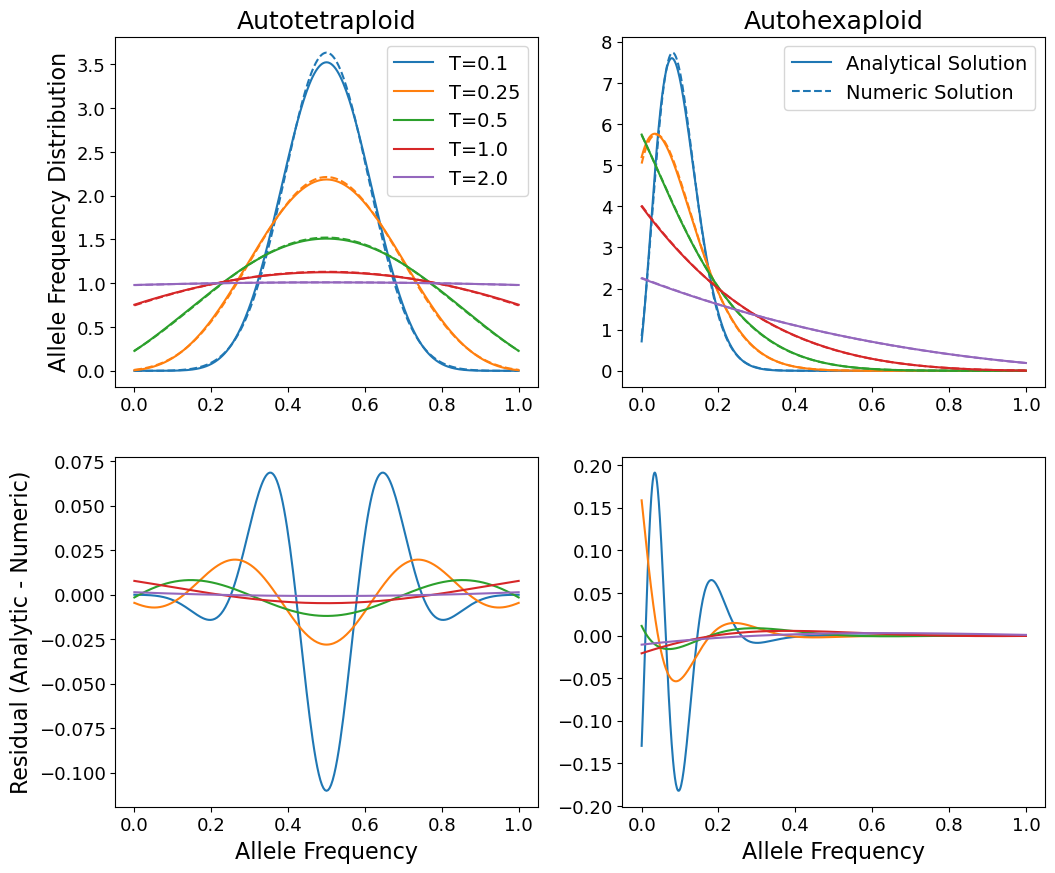

In [ ]:
# set plotting text size
params = {
    'font.size': 14,          # Default text size
    'axes.titlesize': 18,     # Size for Axes titles
    'axes.labelsize': 16,     # Size for x and y labels
    'xtick.labelsize': 13,    # Size for x-axis tick labels
    'ytick.labelsize': 13,    # Size for y-axis tick labels
    'legend.fontsize': 14,    # Size for legend text
    'figure.titlesize': 20    # Size for the figure suptitle
}
plt.rcParams.update(params)


N = 10000
times = [N/5, N/2, N, 2*N, 4*N]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
p0=.5


pts=1001
xx = dadi.Numerics.default_grid(pts)

phi_init = np.zeros_like(xx)
phi_init[500] = 1
tet_flag = dadi.Polyploidy.Integration.PloidyType.AUTO
hex_flag = dadi.Polyploidy.Integration.PloidyType.AUTOHEX  

fig, axs = plt.subplots(2,2, figsize=(12,10))
# tetraploid subpanel
for i, t in enumerate(times):
    analytic = kimura_neutral_autotet(xx, t, p0, N, max_terms=1000)
    diffusion = dadi.Polyploidy.Integration.one_pop(phi_init.copy(), xx, T=t/(2*N), 
                                                    ploidyflag=tet_flag, theta0=0)
    
    # normalize each phi to be a probability density before plotting
    analytic /= np.trapezoid(analytic, xx)
    diffusion /= np.trapezoid(diffusion, xx)
   
    axs[0,0].plot(xx, analytic, label=f'T={t/(2*N)}', color=colors[i])
    axs[0,0].plot(xx, diffusion, label='', color=colors[i], linestyle='--')

    axs[1,0].plot(xx, analytic-diffusion, label=f'', color=colors[i])

axs[0,0].set_title("Autotetraploid")
axs[0,0].set_ylabel("Allele Frequency Distribution")
axs[1,0].set_xlabel("Allele Frequency")
axs[1,0].set_ylabel("Residual (Analytic - Numeric)")
axs[0,0].legend()

phi_init = np.zeros_like(xx)
# for pts=1001, the default grid has frequency .1 at index 363
phi_init[363] = 1
p0=xx[363]

# hexaploid subpanel
for i, t in enumerate(times):
    analytic = kimura_neutral_autohex(xx, t, p0, N, max_terms=1000)
    diffusion = dadi.Polyploidy.Integration.one_pop(phi_init.copy(), xx, T=t/(2*N), 
                                                    ploidyflag=hex_flag, theta0=0)
    
    # normalize each phi to be a probability density before plotting
    analytic /= np.trapezoid(analytic, xx)
    diffusion /= np.trapezoid(diffusion, xx)
    if i == 0:
        axs[0,1].plot(xx, analytic, label='Analytical Solution', color=colors[i])
        axs[0,1].plot(xx, diffusion, label='Numeric Solution', color=colors[i], linestyle='--')
    else:
        axs[0,1].plot(xx, analytic, label='', color=colors[i])
        axs[0,1].plot(xx, diffusion, label='', color=colors[i], linestyle='--')

    axs[1,1].plot(xx, analytic-diffusion, label=f'', color=colors[i])

axs[0,1].set_title("Autohexaploid")
axs[1,1].set_xlabel("Allele Frequency")
axs[0,1].legend()

fig.savefig("kimura_analytic_phi.pdf", bbox_inches='tight', format='pdf', dpi=900)


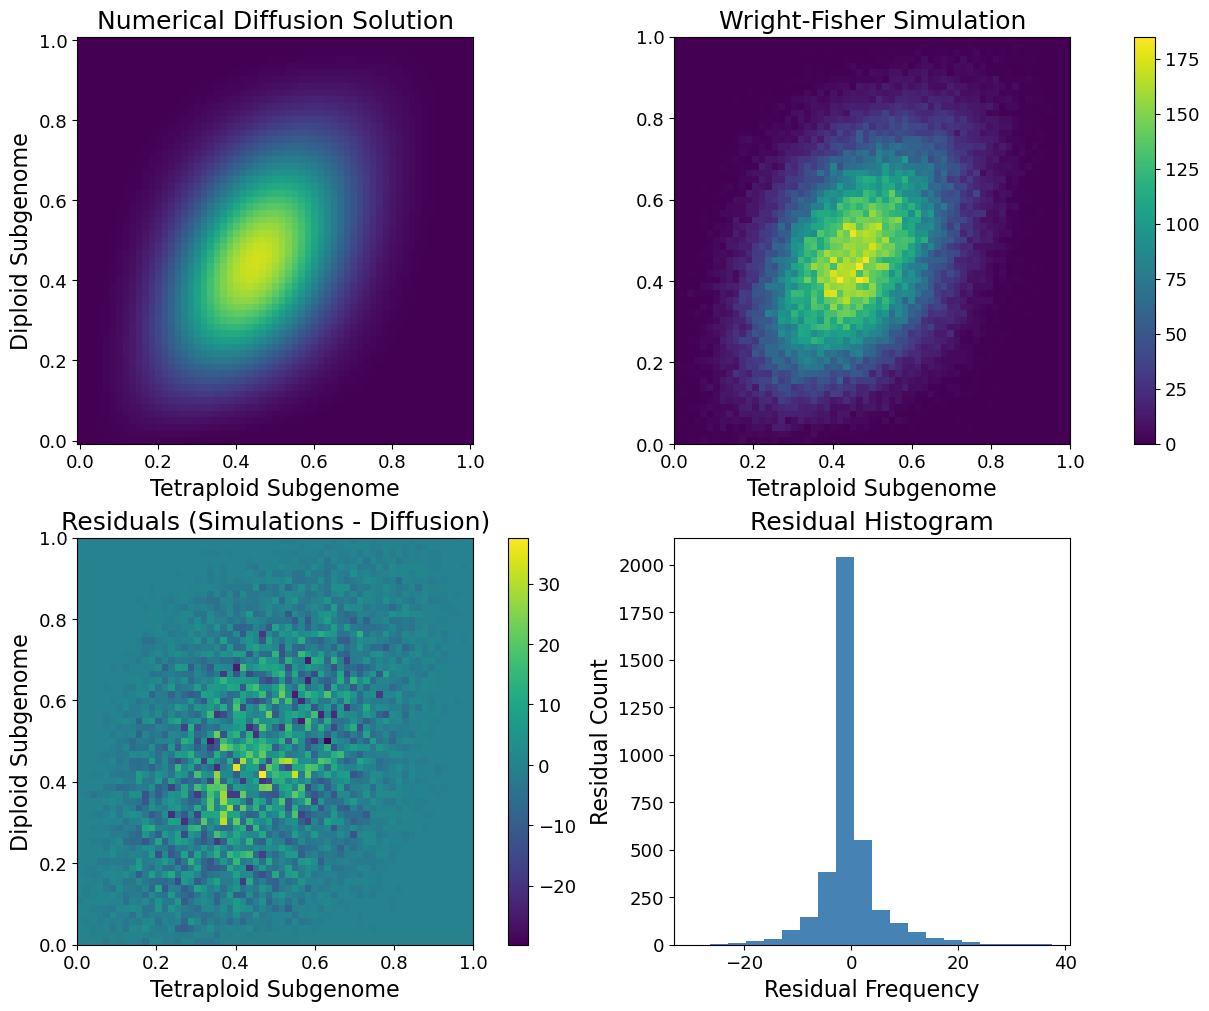

In [192]:
pts=61
replicates = 100000
#xx = dadi.Numerics.default_grid(pts)
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size])

i, j = 30, 30

phi[i,j] = replicates

hex_tetraflag = dadi.Polyploidy.Integration.PloidyType.HEX_tetra
hex_dipflag = dadi.Polyploidy.Integration.PloidyType.HEX_dip
T = .1
gamma = -5
e12 = m12 = m21 = 10
sel_dict = {'gamma': gamma}
sel_vec = hex_tetraflag.pack_sel_params(sel_dict)
nu1 = .25
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = .25
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
N = 10000

# integrate the diffusion model
phi = dadi.Polyploidy.Integration.two_pops(phi, xx, T, nu1_func, nu2_func, m12, m21, sel_dict, sel_dict, hex_tetraflag, hex_dipflag, theta0=0)

# plot the result from the diffusion model
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

fig, axs = plt.subplots(2,2, figsize=(12,10), constrained_layout=True)

im00 = axs[0,0].imshow(phi.T, extent=[edges[0], edges[-1], edges[0], edges[-1]], cmap='viridis', origin='lower', aspect='auto')
axs[0,0].set_xlabel('Tetraploid Subgenome')
axs[0,0].set_ylabel('Diploid Subgenome')
axs[0,0].set_title('Numerical Diffusion Solution')

allele_freqs = dadi.Polyploidy.wrightfisher.hex_4_2_WF(N, T, e12, s=sel_vec, init_q4=np.full(replicates,xx[i]), 
                             init_q2=np.full(replicates,xx[j]), replicates=replicates, nu = nu1_func)

# separate diploid and auto frequencies
alloa_freqs = allele_freqs[0, :]
allob_freqs = allele_freqs[1, :]

alloa_edges = np.linspace(0, 1, pts+1)
allob_edges = np.linspace(0, 1, pts+1)
hist, xedges, yedges = np.histogram2d(x=alloa_freqs.flatten(), y=allob_freqs.flatten(), bins=[alloa_edges, allob_edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# sync color range across top two plots for shared colorbar
vmin_top = min(phi.min(), hist.min())
vmax_top = max(phi.max(), hist.max())
im00.set_clim(vmin_top, vmax_top)

# Transpose due to row/column orientation
im01 = axs[0,1].imshow(hist.T, cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto',
                        vmin=vmin_top, vmax=vmax_top)
axs[0,1].set_xlabel('Tetraploid Subgenome')
axs[0,1].set_title('Wright-Fisher Simulation')

fig.colorbar(im01, ax=[axs[0,0], axs[0,1]])

im10 = axs[1,0].imshow((phi.T - hist.T), cmap='viridis', origin='lower', extent=[0, 1, 0, 1], aspect='auto')
axs[1,0].set_xlabel('Tetraploid Subgenome')
axs[1,0].set_ylabel('Diploid Subgenome')
axs[1,0].set_title('Residuals (Simulations - Diffusion)')

fig.colorbar(im10, ax=axs[1,0])

residuals = phi.T - hist.T
# plot a histogram of the residuals
residuals = residuals.flatten()

axs[1,1].hist(residuals, bins=20, color='steelblue')
axs[1,1].set_xlabel('Residual Frequency')
axs[1,1].set_ylabel('Residual Count')
axs[1,1].set_title('Residual Histogram')

fig.savefig("wright_fisher_phi.pdf", bbox_inches='tight', format='pdf', dpi=900)